# Food Hub Analysis Project

## Objective of the project
The goal of this analysis is to explore and understand the provided data to answer key business questions and generate actionable insights.
Specifically, this analysis aims to:

* Understand demand patterns — Identify which restaurants and cuisine types are most popular, and how demand varies between weekdays and weekends.
* Evaluate operational efficiency — Assess food preparation and delivery times to identify bottlenecks that may be impacting customer experience.
* Analyse customer behaviour — Examine order costs, rating habits, and repeat customer activity to better understand the FoodHub customer base.
* Assess revenue performance — Calculate the net commission revenue generated across orders and identify opportunities to grow it.
* Support data-driven decisions — Provide conclusions and recommendations that FoodHub's business and operations teams can act on to improve customer satisfaction, restaurant partnerships, and overall platform performance.



## Data Dictionary 
* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Importing the necessary libraries

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
%matplotlib inline

print("All libraries imported successfully.")

All libraries imported successfully.


### Loading the dataset

In [41]:
foodhub_df=pd.read_csv('foodhub_order.csv')

### Data Sanity Checks

#### Checking the first ten rows of the dataframe

In [42]:
foodhub_df.head(10)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30
8,1477174,121706,Anjappar Chettinad,Indian,16.44,Weekday,5,21,26
9,1477311,39705,Bukhara Grill,Indian,7.18,Weekday,5,29,26


#### Checking the total number of rows and columns of the dataframe

In [43]:
foodhub_df.shape

print(f'The number of rows are {foodhub_df.shape[0]} , columns are {foodhub_df.shape[1]}')

The number of rows are 1898 , columns are 9


#### Checking the dimension of the dataframe

In [44]:
foodhub_df.size

print (f'The dimension of the dataset is {foodhub_df.size}')

The dimension of the dataset is 17082


#### Checking the description of the dataframe

In [45]:
print(('='*60))
print('The description of the numeric columns are given below')
foodhub_df.describe()

The description of the numeric columns are given below


,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


The description of the dataframe include statistical information on the numeric columns. The ouput above gives such information.

In [46]:
print(('='*60))
print('The description of the columns with texts are given below')
foodhub_df.describe(include='object')

The description of the columns with texts are given below


,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


The description of the columns with texts as values are given in the output above.

#### Checking the values that are duplicated in the dataframe

In [47]:
foodhub_df.duplicated().sum()
print (f'The total number of duplicates in the dataset is {foodhub_df.duplicated().sum()}')

The total number of duplicates in the dataset is 0


#### checking the data types of each column

print ('The data types of the column values of the dataset are below ')
print(('='*60))
foodhub_df.dtypes

From the ouput above,the data type of each column is appropraite.

### checking the total number of null values in each column

In [48]:
print (f'The total number of duplicates in the dataset is \n{foodhub_df.isnull().sum()}')

The total number of duplicates in the dataset is 
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


The output above shows that, there are no null values in the dataframe from each column

## The number of orders that are not rated

In [49]:
foodhub_df['rating'].isin(['Not given']).sum()
print(f'The total number of orders that are not rated are {foodhub_df['rating'].isin(['Not given']).sum()}')

The total number of orders that are not rated are 736


## Exploratory Data Analysis

### Univariate Analysis
Analysing one variable at a time.

In [50]:
foodhub_df['order_id'].nunique()

1898

The number of unique values under the order id are 1898

In [51]:
foodhub_df['order_id'].unique()

array([1477147, 1477685, 1477070, ..., 1477819, 1477513, 1478056],
      shape=(1898,))

In [52]:
foodhub_df['restaurant_name'].nunique()

178

The number of unique values under the restaurant name are 178

In [53]:
foodhub_df['restaurant_name'].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind TriBeCa', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill',
       'Big Wong Restaurant \x8c_¤¾Ñ¼', 'Empanada Mama (closed)', 'Pylos',
       "Lucky's Famous Burgers", 'Shake Shack', 'Sushi of Gari',
       'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'Sushi of Gari 46', 'The Kati Roll Company', 'Klong',
       '5 Napkin Burger', 'TAO', 'Parm', 'Sushi Samba',
       'Haru Gramercy Park', 'Chipotle Mexican Grill $1.99 Delivery',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger',
       "Sarabeth's East", 'Hill Country Fried Chicken', 'Bistango',
       "Jack's Wife Freda", "Mamoun's Falafel", 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Br

#### Top ten restaurants

In [54]:
print('The top ten restaurants are as below')
print('='*60)
top_10 = foodhub_df['restaurant_name'].value_counts().nlargest(10)
top_10 = top_10.sort_values(ascending=False)
top_10

The top ten restaurants are as below


restaurant_name
Shake Shack                      219
The Meatball Shop                132
Blue Ribbon Sushi                119
Blue Ribbon Fried Chicken         96
Parm                              68
RedFarm Broadway                  59
RedFarm Hudson                    55
TAO                               49
Han Dynasty                       46
Blue Ribbon Sushi Bar & Grill     44
Name: count, dtype: int64

The output above indicates the top ten restaurants

##### Plotting the top ten restaurants

Text(0.5, 1.0, 'Top Ten Most Popular Restaurants')

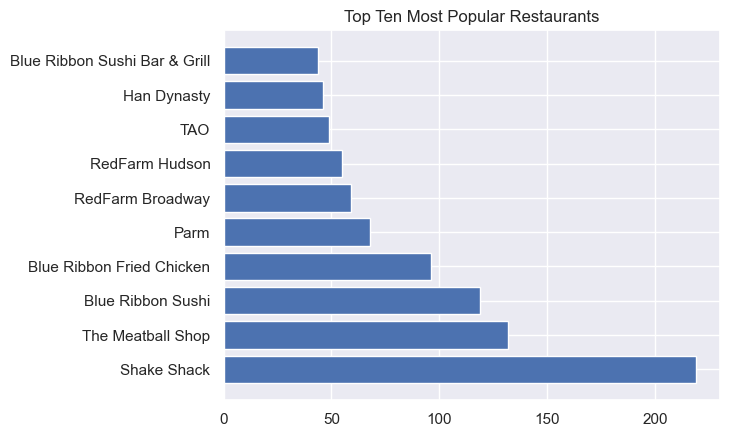

In [55]:
plt.barh(y=top_10.index,
           width = top_10.values)
plt.title('Top Ten Most Popular Restaurants')

The output above is a horizontal bar chart that shows the ten restaurants with the most orders. Shake Shack leads with 219 orders,
with Blue Ribbon Sushi Bar & grill being the least on the list with 44 orders.

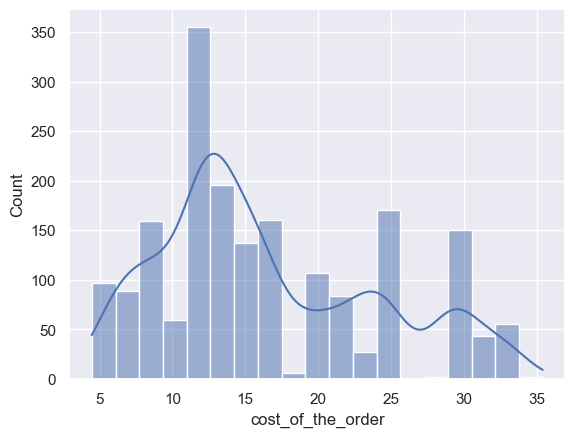

In [56]:
sns.histplot(data=foodhub_df,x='cost_of_the_order',kde=True);

The output above shows a histogram with a kernel density distribution estimate curve, showing the spread of order costs. The 
distribution is rightly skewed, meaning most orders made did not cost more than 20 dollars.

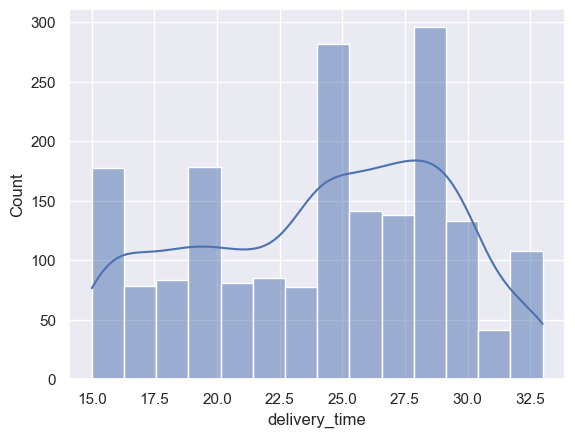

In [57]:
sns.histplot(data=foodhub_df, x='delivery_time',kde=True);

The ouput shows a histogram with kernel distribution estimate curve, which shows how delivery times are distributed across all orders.The distribution is spread out across roughly 15–33 minutes.

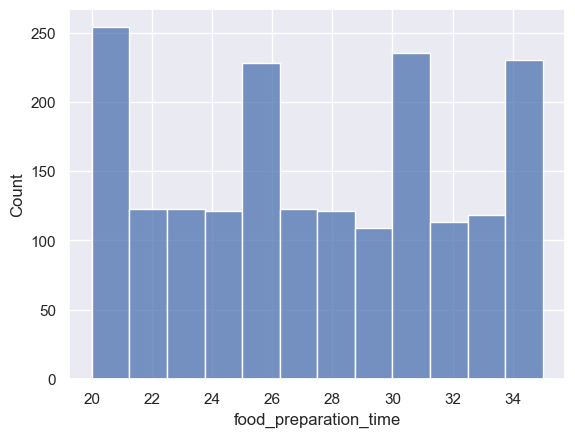

In [58]:
sns.histplot(data=foodhub_df, x='food_preparation_time');

The output shows a histogram. The distribution above shows roughly uniform between 20–35 minutes.

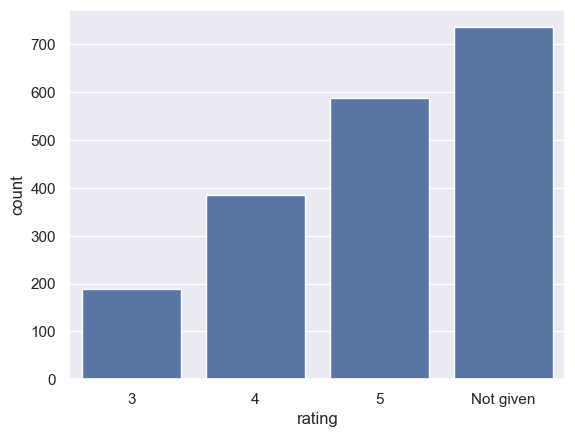

In [59]:
sns.countplot(
    data=foodhub_df,
    x='rating',
    order=foodhub_df['rating'].value_counts().sort_values().index
);

The bar chart above shows the frequency of each rating value. "Not given" is the most frequent category (above 700 orders),
 Among rated orders, ratings of 5 appear to be the most common, followed by 4 and 3.

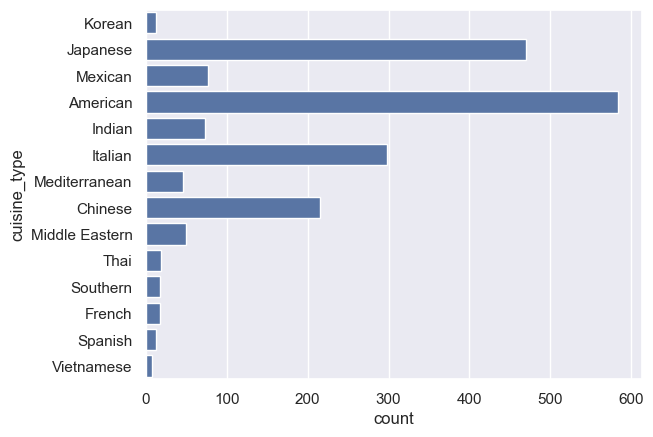

In [60]:
sns.countplot(data=foodhub_df,y='cuisine_type');

The chart shows the number of orders by cuisine type. American cuisine is the most ordered (584 orders),
followed by Japanese and Italian. This gives a clear picture of customer preferences.

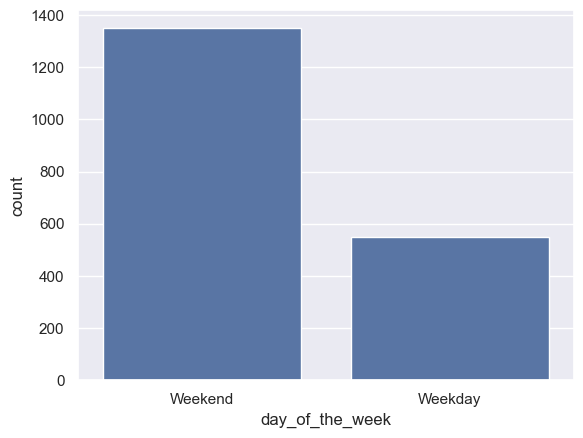

In [61]:
sns.countplot(data=foodhub_df,x='day_of_the_week');

The output shows a bar chart comparing weekday and weekend orders. Weekends are significantly more popular (above 1200 orders) than weekdays.

## Top Five Restaurants in terms of number of orders received

In [62]:
foodhub_df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


## Popular Weekend Cuisines

In [63]:
popular_weekend_cuisine = foodhub_df.groupby(['cuisine_type','day_of_the_week'],as_index=False)['order_id'].count()\
        .rename(columns={'order_id':'counts'})\
        .sort_values(by='counts',ascending=False)\
        .reset_index(drop=True)

In [64]:
popular_weekend_cuisine[popular_weekend_cuisine['day_of_the_week']=='Weekend']

,cuisine_type,day_of_the_week,counts
0,American,Weekend,415
1,Japanese,Weekend,335
2,Italian,Weekend,207
4,Chinese,Weekend,163
7,Mexican,Weekend,53
9,Indian,Weekend,49
10,Middle Eastern,Weekend,32
11,Mediterranean,Weekend,32
15,Thai,Weekend,15
17,French,Weekend,13


## The Percentage of orders that cost more than 20 dollars

In [65]:
orders_above_20 = foodhub_df[foodhub_df['cost_of_the_order'] > 20].shape[0]
total_orders = foodhub_df.shape[0]
percentage_above_20 = (orders_above_20 / total_orders) * 100
print('Percentage of orders costing more than 20 dollars:', round(percentage_above_20, 2), '%')

Percentage of orders costing more than 20 dollars: 29.24 %


## The Mean Delivery time

In [66]:
mean_avg_time = foodhub_df['delivery_time'].mean().round(2)
print('Mean Order Deliver time is:',mean_avg_time)

Mean Order Deliver time is: 24.16


## The Top Three Customers

In [67]:
top_three_customers = foodhub_df['customer_id'].value_counts().nlargest(3)

print(f'The top three customers are\n{top_three_customers}')

The top three customers are
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


The output above indicates the top three customers and the number of orders they placed in descending order

## Bivariate/Multivariate analysis
Analysis that involves two or  more variables

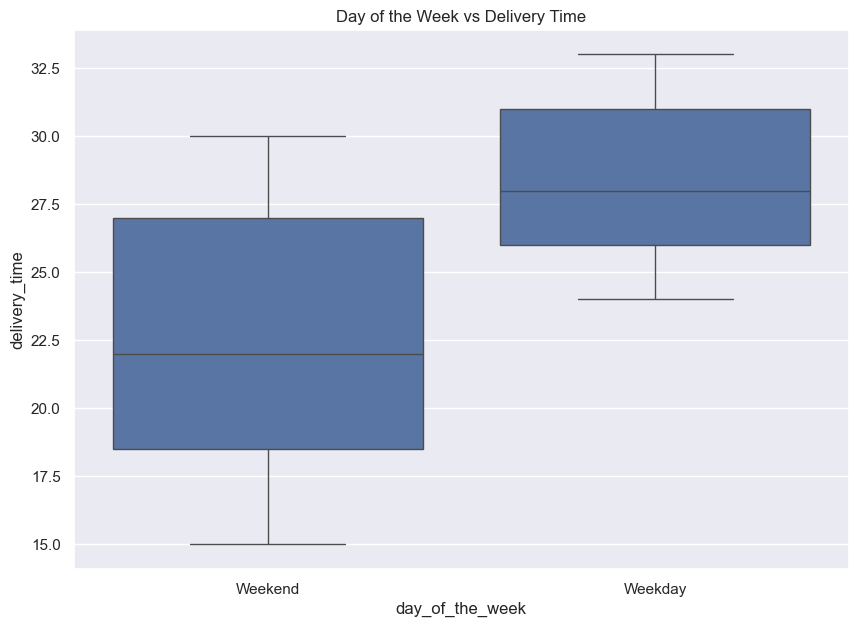

In [68]:
plt.figure(figsize=(10,7))
sns.boxplot(data=foodhub_df, x='day_of_the_week', y='delivery_time')
plt.title('Day of the Week vs Delivery Time')
plt.show()

The box plot above compares the distribution of delivery times on weekdays and weekends. Weekend delivery times have a notably lower median (~22.5 min) than weekdays (~28.3 min).

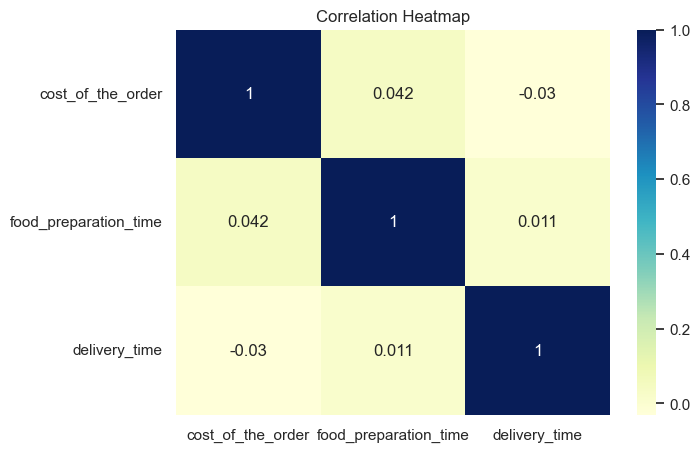

In [69]:
plt.figure(figsize=(7,5))
sns.heatmap(foodhub_df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

The heat map shows correlations between cost of order, food preparation time and delivery time. All three correlations are near zero, meaning these variables are essentially uncorrelated with each other — cost doesn't predict preparation time, and preparation time also
doesn't predict delivery time.

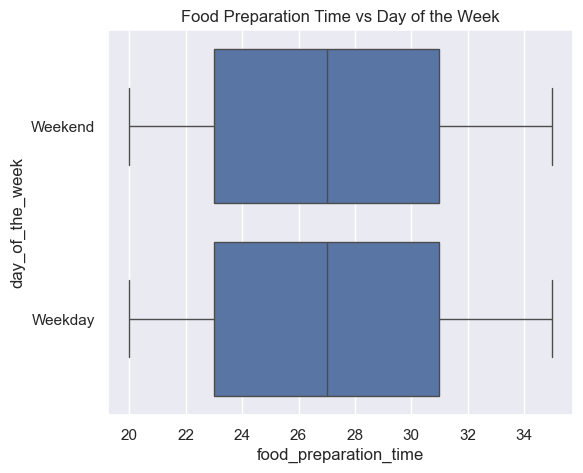

In [70]:
plt.figure(figsize=(6,5))
sns.boxplot(data=foodhub_df, x='food_preparation_time', y='day_of_the_week')
plt.title('Food Preparation Time vs Day of the Week')
plt.show()

The boxplot compares how long food preparation takes on weekdays and weekends. 
The distributions appear very similar, suggesting day of the week doesn't meaningfully affect kitchen speed.

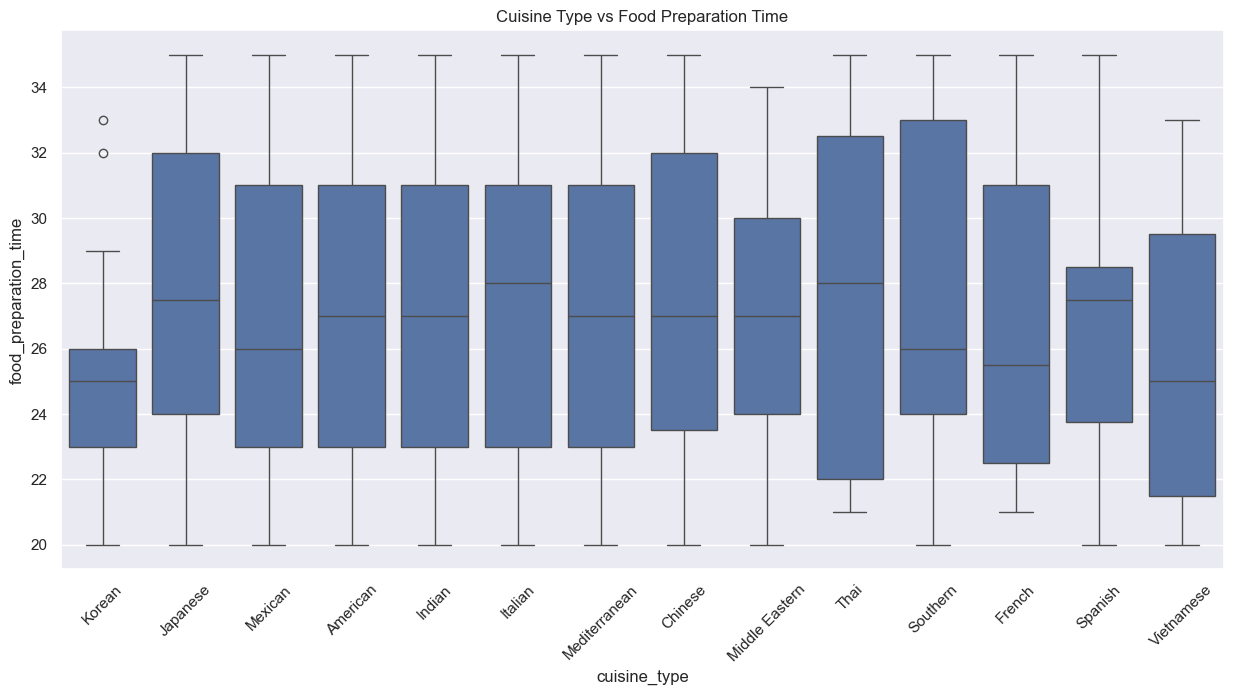

In [71]:
plt.figure(figsize=(15,7))
sns.boxplot(data=foodhub_df, x='cuisine_type', y='food_preparation_time')
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Food Preparation Time')
plt.show()

The box plot shows preparation time across all 14 cuisine types. Most cuisines cluster around 25–30 minutes, though some (e.g., Korean, Mediterranean) show wider variance and higher outliers.

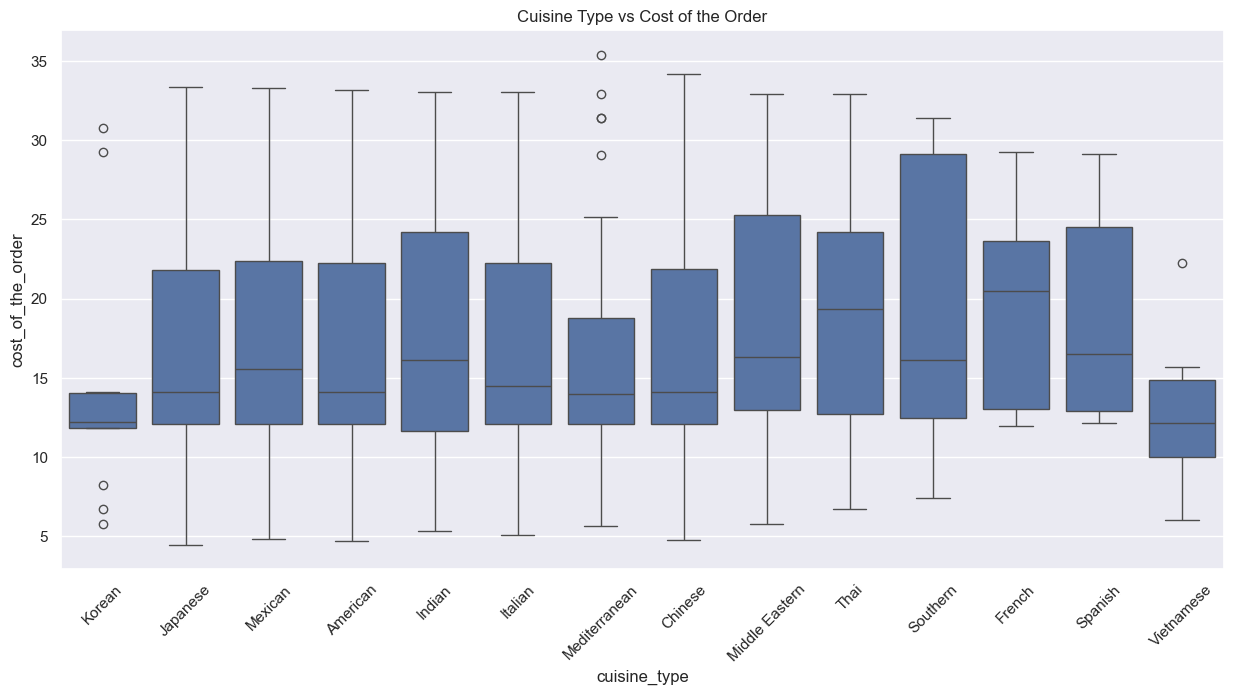

In [72]:
plt.figure(figsize=(15,7))
sns.boxplot(data=foodhub_df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Cost of the Order')
plt.show()

The box plot shows how order costs vary by cuisine. Some cuisines like Korean and Japanese tend to be more expensive, while American and Chinese skew cheaper.

## Restaurants that qualify for promotional offers
Conditions to qualify include;
1. Rating count of more than 50
2. Average rating should be more than 4

In [73]:
foodhub_df['rating'] = foodhub_df['rating'].replace('Not given', np.nan)
foodhub_df['rating'] = pd.to_numeric(foodhub_df['rating'])

# Group by restaurant and calculate rating count and average rating
restaurant_ratings = foodhub_df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

restaurant_ratings.head()

,count,mean
restaurant_name,,
'wichcraft,1,5.0
12 Chairs,2,4.5
5 Napkin Burger,2,4.0
67 Burger,1,5.0
Alidoro,0,NaN


In [74]:
# Filtering restaurants based on conditions
qualified_restaurants = restaurant_ratings[
    (restaurant_ratings['count'] > 50) &
    (restaurant_ratings['mean'] > 4)
]

# Sorting results
qualified_restaurants = qualified_restaurants.sort_values(by='count', ascending=False)

# Displaying results

qualified_restaurants

,count,mean
restaurant_name,,
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905
Blue Ribbon Sushi,73,4.219178
Blue Ribbon Fried Chicken,64,4.328125


According to the conditions given, Shake Shack, The Meatball Shop, Blue Ribbon Sushi and Blue Ribbon Fried Chicken qualify.

### Net Revenue generated by the company across all orders

In [75]:
# creating a column called commission, then finding the commission percentage
foodhub_df['commission']= np.select(
    condlist=[
        foodhub_df['cost_of_the_order']>20,
        foodhub_df['cost_of_the_order']>5
    ],
    choicelist=[
        foodhub_df['cost_of_the_order']*0.25,
        foodhub_df['cost_of_the_order']*0.15
    ],
    default=0
)

In [76]:
foodhub_df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,commission
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,1.7385


In [77]:
# finding the net revenue
net_revenue = foodhub_df['commission'].sum()
print(f'\nNet Revenue of the company is ${net_revenue:.2f}')


Net Revenue of the company is $6166.30


## The Percentage of Orders that takes more than one to be delivered

In [78]:
# Creating a column : total delivery time
foodhub_df['total_time'] = foodhub_df['food_preparation_time'] + foodhub_df['delivery_time']

In [79]:
foodhub_df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,commission,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,7.6875,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,1.8120,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,1.8345,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,7.3000,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,1.7385,49


In [80]:
#checking the delivery times that took more than 60 minutes
over_one_hour = foodhub_df[foodhub_df['total_time'] > 60]
over_one_hour.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,commission,total_time
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,0.8955,63
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,NaN,34,28,0.8880,62
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.20,Weekend,4.0,35,26,2.4300,61
24,1476714,363783,Cafe Mogador,Middle Eastern,15.86,Weekday,NaN,32,29,2.3790,61
54,1477760,130507,Jack's Wife Freda,Mediterranean,22.75,Weekend,3.0,35,29,5.6875,64


In [81]:
#finding the percentage
total_orders = foodhub_df.shape[0]
percentage = (over_one_hour.shape[0] / total_orders) * 100
print(f"Percentage of orders over 60 mins: {round(percentage, 2)}%")

Percentage of orders over 60 mins: 10.54%


## Difference between weekdays and weekends mean delivery times

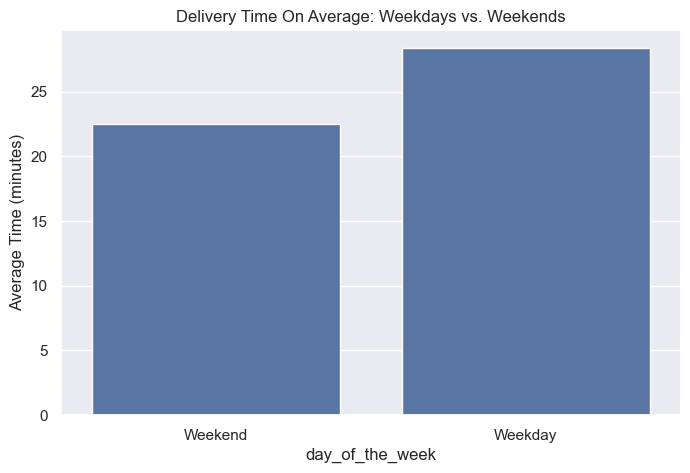

In [82]:
plt.figure(figsize=(8,5))
sns.barplot(data=foodhub_df, x='day_of_the_week', y='delivery_time', estimator='mean', errorbar=None)
plt.title('Delivery Time On Average: Weekdays vs. Weekends')
plt.ylabel('Average Time (minutes)')
plt.show()

In [83]:
avg_delivery_time = foodhub_df.groupby('day_of_the_week', as_index=False)['delivery_time'].mean().round(2)
print(avg_delivery_time)

  day_of_the_week  delivery_time
0         Weekday          28.34
1         Weekend          22.47


The bar chart confirms that the average weekday delivery time (28.3 min) is notably longer than weekend delivery time (22.5 min).

# Conclusions and Recommendations

## Conclusions

The FoodHub dataset contains 1,898 orders across 178 restaurants and 14 cuisine types, with no missing or duplicate values. The key findings from the analysis are:

1. Demand & Popularity
Weekend orders (1,351) significantly outnumber weekday orders (547), indicating that demand is heavily concentrated on Saturdays and Sundays.
American cuisine is the most ordered by a wide margin (584 orders), followed by Japanese and Italian. These three dominate both weekday and weekend demand.
Shake Shack is the single most popular restaurant with 219 orders — nearly double the second-place Meatball Shop (132).

2. Cost & Revenue
The average order cost is approximately $16.50, and only 29.24% of orders exceed $20.
FoodHub's net commission revenue across all orders is $6,166.30, based on a 25% commission on orders above $20 and 15% on orders between $5–$20.

3. Delivery & Preparation
Average food preparation time is ~27 minutes and average delivery time is ~24 minutes, giving a combined average of ~51 minutes per order.
10.54% of orders take more than 60 minutes in total — a notable proportion that risks customer dissatisfaction.
Weekday deliveries average 28.3 minutes, compared to only 22.5 minutes on weekends, a difference worth investigating.

4. Ratings
736 orders (38.8%) were left unrated — a very high proportion that limits the reliability of rating-based analysis.
Among the restaurants that qualified for promotional offers (more than 50 rated orders and an average rating above 4), only four restaurants met the bar: Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken

## Recommendations

1. Investigate and reduce long delivery times

2. Address the rating gap

3. Prioritise top-performing restaurants

4. Capitalise on weekend demand
 
5. Grow the high-value order segment

6. Expand cuisine diversity and support underrepresented restaurants
